# 10. Play calling on early downs: personnel and run or pass (M7b)

**License: CC BY-SA 4.0.** The actions are offensive personnel groupings from nflverse participation data (NFL Next Gen Stats via nflverse 2016-2022, FTN Data via nflverse 2023+), so every number in this notebook is share-alike.

The question: *on 1st and 2nd down, which personnel grouping and which call (run or pass) gains the most EPA in a given situation?* The method is `context/ml-m7-method.md`, section 4; the build notes and the holdout pre-registration are in `context/ml.md` ("M7b build notes"). Everything here is **development data, 2018-2019**: the holdout seasons 2020-2025 are not touched.

This is a causal question, and that's the whole difficulty. Teams choose personnel *because of* the situation, so comparing raw averages mixes the effect of the call with the effect of the spot on the field. This notebook walks through why, and through the tools that deal with it: propensity scores, the doubly robust (AIPW) estimator, overlap, off-policy evaluation, and a placebo test.

Results come from the experiment registry (`experiments/runs/`, runs `m7b_*`, label `m7bdev`) and the saved per-play frame from `python scripts/ml_m7b.py dev`.

In [1]:
import json
import sys
import warnings
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "nflelo").is_dir())
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore", message="X does not have valid feature names")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nflelo.ml import data as D
from nflelo.ml import registry
from nflelo.ml.decisions import policy as pol

plt.rcParams.update({"figure.figsize": (9, 3.6), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
pd.set_option("display.width", 170)
INK, ACCENT, MUTED, BAD, MODEL = "#1f2a44", "#2f6fdf", "#9aa3b2", "#d1495b", "#2a9d8f"

# the latest dev record of every M7b run in the registry
runs = [r for r in registry.load_runs() if r["name"].startswith("m7b_") and r["label"] == "m7bdev"]
RUN = {}
for r in sorted(runs, key=lambda r: r["timestamp"]):
    RUN[r["name"]] = r
print("runs:", sorted(RUN), "| commit", {r["git"]["sha"][:7] for r in RUN.values()},
      "| dirty", {r["git"]["dirty"] for r in RUN.values()})

OUT = D.ML_DIR / "m7b"
P = pd.read_parquet(OUT / "plays_m7bdev.parquet")       # every 2018-2019 early-down play, season-ahead nuisances
A = list(pol.ACTIONS)
P["act"] = np.array(A)[P["action"].to_numpy()]
P["group"] = P["act"].str.split("_").str[0]
P["zone"] = P["cell"].str.split(" | ", regex=False).str[1]
P["heavy"] = P["group"].isin(["13", "oth"])      # three tight ends, or the pooled heavy / jumbo looks
print(f"{len(P):,} plays in {P['game_id'].nunique()} games; mean EPA {P['y_epa'].mean():+.3f}")

def ci(c, nd=3):
    return f"{c['diff']:+.{nd}f} [{c['ci_low']:+.{nd}f}, {c['ci_high']:+.{nd}f}]"

runs: ['m7b_ope', 'm7b_ope_thr10', 'm7b_ope_trim10', 'm7b_outcome', 'm7b_placebo', 'm7b_policy', 'm7b_propensity', 'm7b_team_view'] | commit {'4e509da'} | dirty {True}
39,056 plays in 534 games; mean EPA +0.017


## 1. The actions and the situations

**Actions (12).** Offensive personnel grouping × run or pass. The grouping is the standard "RB count, TE count" code: 11 is one back and one tight end (three receivers), 12 is one back and two tight ends, 21 is two backs, 13 is three tight ends, 10 is four receivers. Everything else (22, 20, a sixth offensive lineman, empty backfields) is pooled as "oth". A pass is nflfastR's `pass` flag, so sacks and scrambles count as passes.

**Sample.** 1st and 2nd downs outside the last two minutes of each half, with garbage time already removed (nflfastR win probability outside 5-95%). End-of-half plays follow clock rules rather than play-calling preferences.

**Situation cells (60).** Down and distance (1st and 10+, 1st and short, 2nd and 1-3, 4-7, 8+) × field zone (own 1-20, own 21-50, opponent 49-21, red zone) × score (trailing by 4+, within 3, leading by 4+). The models use the exact situation; the cells are for reporting and for the recommendations.

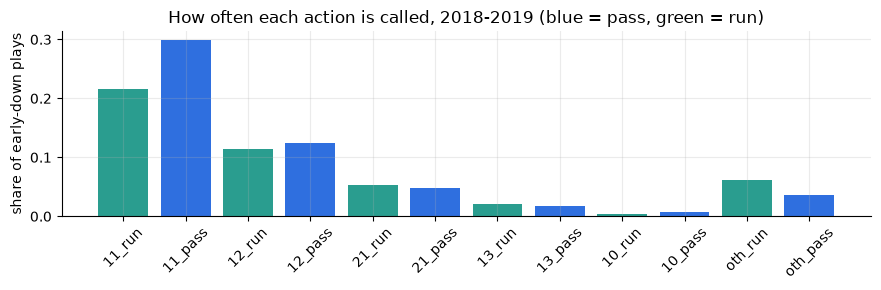

In [2]:
mix = P["act"].value_counts(normalize=True).reindex(A)
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(A, mix.to_numpy(), color=[ACCENT if a.endswith("pass") else MODEL for a in A])
ax.set_ylabel("share of early-down plays"); ax.set_title("How often each action is called, 2018-2019 (blue = pass, green = run)")
plt.xticks(rotation=45); plt.tight_layout()

Two actions (11 personnel run and pass) cover half the plays; 12 personnel another quarter. Heavy looks (13 personnel, plus the pooled "oth" group, which holds 22 personnel and the jumbo sets with an extra lineman) are rarer, and they aren't spread evenly over the field.

## 2. Confounding, with a football example: heavy personnel at the goal line

Start with yards per play, the obvious outcome, by field position:

In [3]:
band = pd.cut(P["yardline_100"], [0, 2, 5, 10, 20, 50, 80, 99],
              labels=["1-2", "3-5", "6-10", "11-20", "21-50", "51-80", "81-99"])
by = P.groupby(band, observed=True).apply(lambda d: pd.Series({
    "plays": len(d), "heavy share": d["heavy"].mean(), "yards": d["yards"].mean(), "EPA": d["y_epa"].mean()}))
print("yards to the end zone, early downs 2018-2019:")
print(by.round(3).to_string())
raw = P.groupby("heavy")[["yards", "y_epa"]].mean().rename(index={False: "other personnel", True: "heavy personnel"})
print("\nraw averages:")
print(raw.round(3).to_string())

yards to the end zone, early downs 2018-2019:
                plays  heavy share  yards    EPA
yardline_100                                    
1-2             560.0        0.527  0.554  0.053
3-5             682.0        0.144  1.724  0.023
6-10           1162.0        0.165  2.943  0.051
11-20          2789.0        0.151  4.490  0.019
21-50         11072.0        0.133  5.838  0.027
51-80         19082.0        0.118  6.300  0.009
81-99          3709.0        0.154  6.270  0.011

raw averages:
                 yards  y_epa
heavy                        
other personnel  5.869  0.021
heavy personnel  5.173 -0.011


Inside the 2-yard line, more than half the early-down calls use heavy personnel, against 12-17% everywhere else. And inside the 2 a play *can't* gain many yards: the end zone is right there. So heavy personnel's raw yards per play look bad partly because of **where** it's called. The situation (field position) drives **both** the choice of heavy personnel **and** the outcome. That's a confounder: the raw comparison mixes "heavy personnel gains less" with "heavy personnel is used where every play gains less."

The first fix is to compare like with like, within the same situation:

In [4]:
rows = []
for name, d in (("all plays", P), ("inside the 2", P[P["yardline_100"] <= 2]),
                ("between the 20s", P[P["yardline_100"].between(21, 80)])):
    m = d.groupby("heavy")[["yards", "y_epa"]].mean()
    rows.append({"plays": name, "n heavy": int(d["heavy"].sum()),
                 "yards: heavy minus other": m.loc[True, "yards"] - m.loc[False, "yards"],
                 "EPA: heavy minus other": m.loc[True, "y_epa"] - m.loc[False, "y_epa"]})
print(pd.DataFrame(rows).round(3).to_string(index=False))

          plays  n heavy  yards: heavy minus other  EPA: heavy minus other
      all plays     5309                    -0.696                  -0.032
   inside the 2      295                    -0.274                   0.073
between the 20s     3731                    -0.252                  -0.012


Within a field-position band the yards gap shrinks from -0.70 to about -0.25. And **EPA barely shows the goal-line effect at all**: EPA measures a play against the expected points of its own down, distance and spot, so a 1-yard touchdown run counts for a lot even though it gained 1 yard. Inside the 2, heavy personnel is actually ahead on EPA. That's one reason EPA is the outcome here: it removes the field-position part of this confounding by construction.

It doesn't remove the rest. Teams also choose by score, time, down and distance, their own strengths and the opponent's, and their habits, and every one of those affects EPA too. Stratifying works only for confounders we cut on, and the cells get thin fast. That's what the next tools are for.
## 3. Propensity scores

The **propensity score** of an action is the probability that the team calls it, given everything known before the snap: e_a(x) = P(A = a | x). If two plays have the same propensity for heavy personnel, then whether heavy personnel was actually called is, as far as the features can tell, a coin flip, and comparing them is fair *with respect to those features*.

Our propensity model is a multiclass gradient-boosted classifier over the 12 actions, trained season-ahead (2016..S-1 to predict S). Its inputs: the situation (down, distance, yard line, score, time, timeouts, home, roof, weather), the M3 ratings as of the week start (the offense's pass and rush offense, the opponent's pass and rush defense), and the offense's **tendencies as of the week start**: its early-down mix so far this season, shrunk toward last season's mix (itself shrunk halfway to the league's).

What it may **not** use: offensive personnel (that's the action), and the defense's personnel, the box count and the formation. Those respond to the offensive call; conditioning on them would block part of the effect we're trying to measure, and for a call that wasn't made they're unknown.

In [5]:
pr = RUN["m7b_propensity"]["metrics"]
print(f"multiclass log loss {pr['logloss']:.4f} vs the cell-share baseline {pr['logloss_cell_baseline']:.4f}: "
      f"{ci(pr['logloss_vs_baseline'], 4)}")
cal = pd.DataFrame(pr["calibration"]).T[["share", "mean_pred", "ece", "null_p95", "ok"]]
print(cal.round(4).to_string())

multiclass log loss 1.8487 vs the cell-share baseline 1.9610: -0.1124 [-0.1249, -0.1001]
             share mean_pred       ece  null_p95     ok
11_run    0.215357  0.227758  0.012509  0.005855  False
11_pass   0.298776  0.300564   0.00793  0.006684   True
12_run    0.113734  0.112715  0.002826   0.00387   True
12_pass   0.124078  0.123823   0.00644  0.004187   True
21_run     0.05359  0.050154  0.004367  0.002561   True
21_pass   0.048571  0.045941  0.003543  0.002432   True
13_run    0.020611  0.020381  0.000527  0.001463   True
13_pass   0.016745  0.014709  0.002064  0.001192   True
10_run    0.003201  0.002256  0.000977  0.000491   True
10_pass    0.00676  0.004219  0.002859  0.000761   True
oth_run   0.062142  0.062805  0.004388  0.003167   True
oth_pass  0.036435  0.034675  0.002291  0.001986   True


The propensities are calibrated by the M6 rule (ECE at or below the calibrated-null 95th percentile, or at or below 0.01) for 11 of 12 actions. 11-personnel runs are slightly over-predicted (about 0.228 predicted vs 0.215 called): teams' 2018-2019 run shares fell faster than a season-ahead model expects. The plot shows the heavy-personnel propensity: it's near zero between the 20s and climbs near the goal line.

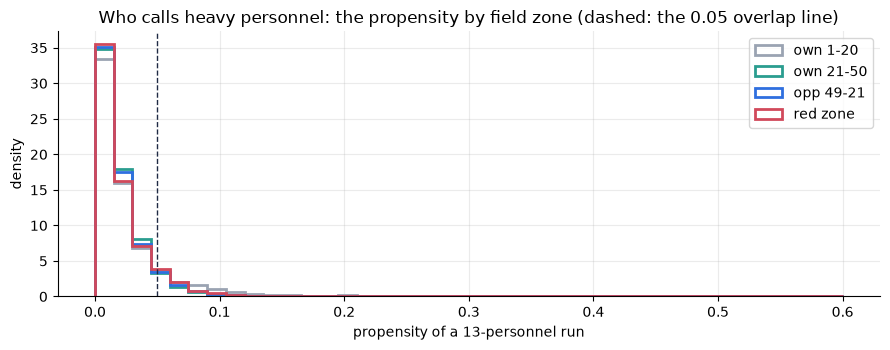

In [6]:
fig, ax = plt.subplots()
for z, col in zip(pol.ZONES, (MUTED, MODEL, ACCENT, BAD)):
    ax.hist(P.loc[P["zone"] == z, "e_13_run"], bins=np.linspace(0, 0.6, 41), histtype="step", lw=2, color=col,
            density=True, label=z)
ax.axvline(pol.OVERLAP, color=INK, ls="--", lw=1)
ax.set_xlabel("propensity of a 13-personnel run"); ax.set_ylabel("density"); ax.legend()
ax.set_title("Who calls heavy personnel: the propensity by field zone (dashed: the 0.05 overlap line)")
plt.tight_layout()

### Overlap

We can only learn what an action does in situations where teams actually use it. The rule: an action is **eligible** for a play only if its propensity there is at least 0.05. Otherwise the play is never used to estimate that action, and the action is never recommended for that play.

In [7]:
ov = RUN["m7b_propensity"]["metrics"]["overlap"]
for k, o in ov.items():
    print(f"threshold {o['thr']}: plays with 2+ eligible actions {o['share_2plus']:.3f}; mean eligible {o['mean_eligible']:.2f} "
          f"of 12; (play, action) pairs eligible {o['share_pairs_eligible']:.3f}; observed call eligible {o['share_observed_eligible']:.3f}")
print(pd.Series(ov["main"]["share_eligible_by_action"]).round(3).to_string())

threshold 0.05: plays with 2+ eligible actions 1.000; mean eligible 5.28 of 12; (play, action) pairs eligible 0.440; observed call eligible 0.886
threshold 0.1: plays with 2+ eligible actions 0.993; mean eligible 3.54 of 12; (play, action) pairs eligible 0.295; observed call eligible 0.757
11_run      1.000
11_pass     0.996
12_run      0.859
12_pass     0.925
21_run      0.390
21_pass     0.373
13_run      0.079
13_pass     0.019
10_run      0.001
10_pass     0.009
oth_run     0.460
oth_pass    0.164


Overlap is good where it matters: nearly every play has several eligible actions (11 run and pass are eligible almost everywhere, 12 on most plays). 10 personnel and 13 passes are almost never eligible: teams use them too rarely to say anything about them.

## 4. AIPW from first principles

Two ways to estimate the average outcome if everyone called action a:

1. **Outcome modelling (regression).** Fit μ_a(x) = E[Y | x, A = a] and average it over all plays. Right if the model is right; biased if it's misspecified, and nothing in the formula notices.
2. **Inverse propensity weighting (IPW).** Average Y over the plays that called a, weighting each by 1 / e_a(x). Plays where a was unlikely but called anyway stand in for the many similar plays where it wasn't. Right if the propensities are right; very noisy when some e_a are small.

**AIPW (augmented IPW, doubly robust)** combines them. For each play i and action a, the pseudo-outcome is

  G_ia = μ_a(x_i) + 1[A_i = a] · (Y_i − μ_a(x_i)) / e_a(x_i)

Start from the model's prediction, then correct it with the propensity-weighted residual on the plays that actually called a. The average of G_ia is consistent if **either** the outcome model **or** the propensity model is right (hence "doubly robust"), and it's usually less noisy than IPW.

**Cross-fitting.** Nuisance models fit on a play and then evaluated on the same play overfit its own residual. So the models used for a season's plays are never fit on that season: for the recommendations, each training season gets models fit on the *other* training seasons; for evaluation, season S gets models fit on 2016..S-1.

A small simulation shows the double robustness. The true effect of the action is +0.30. A confounder z raises both the chance of taking the action and the outcome, and the outcome curves in z. Each estimator runs on 300 simulated data sets of 5,000 plays; the table shows the average estimate and its spread. Case A gives AIPW a wrong (straight-line) outcome model and the right propensity; case B gives it the right outcome model and a wrong (constant) propensity.

In [8]:
def sim(rng, n=5000):
    z = rng.normal(size=n)
    e = 1 / (1 + np.exp(-z))                              # the action is more likely when z is high ...
    a = rng.uniform(size=n) < e
    y = 0.30 * a + np.exp(z) / 2 + rng.normal(0, 1, n)   # ... and z also raises the outcome, on a curve
    return z, e, a, y


def fit_arm(X, y, m):
    return X @ np.linalg.lstsq(X[m], y[m], rcond=None)[0]


rng = np.random.default_rng(0)
res = []
for _ in range(300):
    z, e, a, y = sim(rng)
    Xlin, Xok = np.c_[np.ones_like(z), z], np.c_[np.ones_like(z), np.exp(z)]
    m1, m0 = fit_arm(Xlin, y, a), fit_arm(Xlin, y, ~a)          # wrong outcome model (a straight line)
    r1, r0 = fit_arm(Xok, y, a), fit_arm(Xok, y, ~a)            # right outcome model
    eb = np.full_like(e, a.mean())                              # wrong propensity: ignores z
    aipw = lambda mu1, mu0, p: (mu1 + a * (y - mu1) / p - mu0 - (~a) * (y - mu0) / (1 - p)).mean()  # noqa: E731
    res.append({"naive difference in means": y[a].mean() - y[~a].mean(),
                "outcome model only (wrong, linear)": (m1 - m0).mean(),
                "IPW (right propensity)": (a * y / e).mean() - ((~a) * y / (1 - e)).mean(),
                "A: AIPW, wrong outcome model + right propensity": aipw(m1, m0, e),
                "B: AIPW, right outcome model + wrong propensity": aipw(r1, r0, eb)})
res = pd.DataFrame(res)
print(pd.DataFrame({"mean estimate": res.mean(), "spread (SD)": res.std()}).round(3).to_string())
print("truth: +0.300")

                                                 mean estimate  spread (SD)
naive difference in means                                0.947        0.042
outcome model only (wrong, linear)                       0.262        0.035
IPW (right propensity)                                   0.295        0.082
A: AIPW, wrong outcome model + right propensity          0.295        0.064
B: AIPW, right outcome model + wrong propensity          0.303        0.030
truth: +0.300


The naive comparison is badly biased (about +0.95 for a true +0.30), and the straight-line outcome model misses the curve (+0.26). IPW is unbiased but the noisiest. AIPW is right in both cases: with a wrong outcome model it leans on the propensities (A), and with wrong propensities it leans on the outcome model (B). Either way it's less noisy than IPW.

Now the real example: in the red zone, the DR contrast between a heavy-personnel run and an 11-personnel run, on plays where both are eligible.

In [9]:
from nflelo.ml.eval import bootstrap
r = P[P["zone"] == "red zone"]
for heavy in ("oth_run", "13_run"):
    rb = r[(r[f"e_{heavy}"] >= pol.OVERLAP) & (r["e_11_run"] >= pol.OVERLAP)]
    naive = rb.loc[rb["act"] == heavy, "y_epa"].mean() - rb.loc[rb["act"] == "11_run", "y_epa"].mean()
    nyd = rb.loc[rb["act"] == heavy, "yards"].mean() - rb.loc[rb["act"] == "11_run", "yards"].mean()
    c = bootstrap.cluster_bootstrap_diff((rb[f"g_{heavy}"] - rb["g_11_run"]).to_numpy(), rb["game_id"],
                                         reps=2000, seed=20261003)
    print(f"{heavy} vs 11_run, red-zone plays where both are eligible: {len(rb):,} "
          f"(called {int((rb['act'] == heavy).sum())} and {int((rb['act'] == '11_run').sum())} times)")
    print(f"  raw:  {nyd:+.2f} yards, {naive:+.3f} EPA")
    print(f"  AIPW: {ci(c)} EPA (game-cluster CI)")

oth_run vs 11_run, red-zone plays where both are eligible: 2,834 (called 471 and 668 times)
  raw:  -1.01 yards, -0.007 EPA
  AIPW: -0.002 [-0.114, +0.115] EPA (game-cluster CI)
13_run vs 11_run, red-zone plays where both are eligible: 480 (called 30 and 129 times)
  raw:  -0.54 yards, -0.099 EPA
  AIPW: -0.044 [-0.272, +0.238] EPA (game-cluster CI)


(These are the 2018-2019 evaluation plays, with nuisances fit on earlier seasons.) Heavy-personnel runs gain about a yard less than 11-personnel runs in the red zone. In EPA, once the situation, the teams and their habits are accounted for, the pooled heavy group's difference is zero (CI about ±0.11), and 13 personnel's is within noise (only 30 calls, so its CI is half a point wide). The yards gap was the goal line, not the grouping.

## 5. Cells and recommendations

For each cell and eligible action, the estimate that matters is the **gain over the current mix**: the mean of (G_ia − Y_i) over the cell's plays where a is eligible. It compares "call a" with "what teams actually did" on the same plays. An action is a candidate if it's eligible on at least half the cell's plays and was called at least 30 times there. The recommendation is the candidate with the largest gain, and it's **clear** only if the lower end of its 95% game-cluster CI is above zero. Otherwise the cell is labelled **no clear best**.

The recommendations for season S come only from 2016..S-1 (cross-fit), so they can be scored honestly on S.

In [10]:
pol_run = RUN["m7b_policy"]["metrics"]["recs"]["main"]
for s, x in pol_run.items():
    print(f"recommendations for {s}: {x['clear']} of {x['cells']} cells clear ({x['clear_share']:.2f}; "
          f"{x['plays_in_clear_cells']:.2f} of plays); best actions {x['best_counts']}")
clear19 = pd.DataFrame(pol_run["2019"]["clear_cells"])
print("\nclear cells for 2019 (estimated on 2016-2018), by CI lower bound:")
print(clear19[["cell", "n_cell", "best", "gain", "gain_lo", "gain_hi", "dr_mean", "obs_mean"]].round(3).to_string(index=False))

recommendations for 2018: 14 of 60 cells clear (0.23; 0.54 of plays); best actions {'12_pass': 10, '11_pass': 4}
recommendations for 2019: 17 of 60 cells clear (0.28; 0.61 of plays); best actions {'12_pass': 11, '11_pass': 4, '11_run': 2}

clear cells for 2019 (estimated on 2016-2018), by CI lower bound:
                         cell  n_cell    best  gain  gain_lo  gain_hi  dr_mean  obs_mean
  1-10+ | red zone | within 3    1065 11_pass 0.320    0.185    0.462    0.326     0.005
 1-10+ | opp 49-21 | within 3    3774 12_pass 0.263    0.140    0.380    0.268     0.005
 2-long | own 1-20 | within 3     739 11_pass 0.274    0.124    0.443    0.325     0.051
  1-10+ | own 1-20 | within 3    1516 12_pass 0.218    0.090    0.344    0.170    -0.048
2-long | own 21-50 | within 3    3001 12_pass 0.214    0.088    0.343    0.183    -0.031
  2-mid | opp 49-21 | lead 4+     450 12_pass 0.349    0.077    0.637    0.354     0.006
   1-10+ | own 1-20 | lead 4+     969 12_pass 0.238    0.077    0.403  

The clear recommendations are almost all **passes, mostly from 12 personnel, on 1st and 10 and 2nd and long** (all 14 in 2018 and 15 of 17 in 2019); the two exceptions are 11-personnel runs on short yardage in the red zone. That matches a long-standing finding of public football analytics: early-down passes gain more EPA than early-down runs, and teams run more than EPA alone would suggest. The DR estimate says the pass from 12 personnel is often the best option where it's eligible: play-action from a heavier look is a plausible mechanism, though this analysis can't separate it.

Most cells (over 70%) are **no clear best**: either the actions are within noise of the current mix, or the cell is too thin.

In [11]:
recs = pd.read_parquet(OUT / "recs_m7bdev.parquet")
r19 = recs[(recs["season"] == 2019) & (recs["variant"] == "main")].copy()
parts = r19["cell"].str.split(" | ", regex=False)
r19["dd"], r19["zone"], r19["score"] = parts.str[0], parts.str[1], parts.str[2]
lab = np.where(r19["clear"], r19["best"].fillna(""), "no clear best")
r19["label"] = lab
tab = r19[r19["score"] == "within 3"].pivot(index="dd", columns="zone", values="label").reindex(index=pol.DD, columns=pol.ZONES)
print("2019 recommendations, close games (within 3):")
print(tab.to_string())

2019 recommendations, close games (within 3):
zone          own 1-20      own 21-50      opp 49-21       red zone
dd                                                                 
1-10+          12_pass        11_pass        12_pass        11_pass
1-short  no clear best  no clear best  no clear best         11_run
2-short  no clear best  no clear best  no clear best         11_run
2-mid    no clear best  no clear best  no clear best  no clear best
2-long         11_pass        12_pass  no clear best  no clear best


## 6. Off-policy evaluation: would the recommendations have helped?

The recommended policy for season S: in a cell with a clear recommendation, call it whenever it's eligible for the play; everywhere else, do what the team did. Its value can't be observed, because teams didn't follow it, so we estimate it with the same doubly robust machinery, **on a season the recommendations never saw**: per play, d_i = G_i,a* − Y_i where the policy applies, 0 elsewhere. The mean of d is the EPA per early-down play gained over what teams actually did.

In [12]:
o = RUN["m7b_ope"]["metrics"]
print(f"recommended minus observed, EPA per early-down play: {ci(o['ope_epa'], 4)}")
print(f"success rate: {ci(o['ope_succ'], 4)}")
print(f"the policy applies to {o['share_policy_applies']:.3f} of plays; {o['epa_per_affected_play']:+.3f} EPA per affected play")
print(f"\nsanity check, the observed policy's own DR value minus the observed mean EPA: {ci(o['observed_check_epa'], 4)}")
ps = RUN["m7b_policy"]["per_season"]
for s, v in ps.items():
    print(f"  {s}: OPE {ci(v['ope'], 4)}; observed check {ci(v['observed_check'], 4)}")

recommended minus observed, EPA per early-down play: +0.0743 [+0.0514, +0.0963]
success rate: +0.0442 [+0.0355, +0.0532]
the policy applies to 0.553 of plays; +0.134 EPA per affected play

sanity check, the observed policy's own DR value minus the observed mean EPA: -0.0015 [-0.0027, -0.0003]
  2018: OPE +0.0683 [+0.0401, +0.0981]; observed check -0.0024 [-0.0042, -0.0006]
  2019: OPE +0.0803 [+0.0435, +0.1173]; observed check -0.0005 [-0.0021, +0.0011]


**The gain is clearly positive in both dev seasons**: roughly +0.07 EPA per early-down play over all plays, about +0.13 on the plays where the policy applies. For scale, an offense runs about 37 such plays a game, so that's roughly 2.7 points a game *if the estimates were a fixed truth*, which section 10 explains they aren't.

**Sanity check.** If the observed policy is plugged into the same estimator (weights = the propensities), the DR value should equal the observed mean EPA. It does to about 0.0015 EPA per play, roughly 2% of the estimated gain. The CI just excludes zero, because the check is very precise (both sides use the same plays); the small gap comes from the slightly over-predicted 11-personnel run propensity.

## 7. The placebo

Is there something in the pipeline (picking the best of 12 actions, the bootstrap, the cross-fitting) that manufactures gains out of noise? Test it: **shuffle the actions within each season × cell**, so that within a cell the call has no relation to anything, and rerun the whole pipeline: tendencies, nuisances, cross-fitting, cells, recommendations and OPE. The true gain of any policy is then zero.

In [13]:
pl = RUN["m7b_placebo"]["metrics"]
print(f"placebo OPE, EPA per play: {ci(pl['ope_epa'], 4)}; the policy applies to {pl['share_policy_applies']:.3f} of plays")
for s, x in RUN["m7b_policy"]["metrics"]["placebo_recs"].items():
    print(f"  placebo recommendations for {s}: {x['clear']} of {x['cells']} cells 'clear' by chance")

placebo OPE, EPA per play: -0.0078 [-0.0181, +0.0025]; the policy applies to 0.061 of plays
  placebo recommendations for 2018: 5 of 60 cells 'clear' by chance
  placebo recommendations for 2019: 5 of 60 cells 'clear' by chance


The placebo gain's CI includes zero, as it should. The placebo is also a lesson in **winner's curse**: picking the best of several noisy estimates and checking whether its CI clears zero still finds a few "clear" cells by chance (about 5 of 60 a season here). Those fake recommendations don't carry over to the next season, which is why the honest test is the season-ahead OPE, not the cell CIs.

## 8. Sensitivity

In [14]:
for v, lab in (("m7b_ope", "main (overlap 0.05)"), ("m7b_ope_thr10", "overlap 0.10"),
               ("m7b_ope_trim10", "weights trimmed at 10 (propensity floored at 0.10)")):
    m = RUN[v]["metrics"]
    print(f"{lab:52s} OPE {ci(m['ope_epa'], 4)}; applies to {m['share_policy_applies']:.3f}")

main (overlap 0.05)                                  OPE +0.0743 [+0.0514, +0.0963]; applies to 0.553
overlap 0.10                                         OPE +0.0651 [+0.0460, +0.0822]; applies to 0.475
weights trimmed at 10 (propensity floored at 0.10)   OPE +0.0743 [+0.0518, +0.0959]; applies to 0.565


A stricter overlap rule makes the policy apply to fewer plays and lowers the total gain; trimming the weights changes almost nothing. The result doesn't hinge on a handful of extreme weights.

## 9. A team view: Minnesota, 2019

Minnesota ran one of the most run-first offenses of 2019. What does the league-level analysis say about its own early-down mix? For each action, the estimated gain of switching to it (DR, on Minnesota's 2019 plays where it's eligible, nuisances from 2016-2018), and the league's recommended policy applied to Minnesota's plays.

In [15]:
tv = RUN["m7b_team_view"]["metrics"]
print(f"{tv['team']} {tv['season']}: {tv['plays']} early-down plays, pass share {tv['pass_share']:.3f} "
      f"(league {tv['league_pass_share']:.3f}), mean EPA {tv['obs_epa']:+.3f}")
print(f"the league's recommended policy on MIN's plays: {ci(tv['ope'])} EPA per play (applies to {tv['share_policy_applies']:.2f})")
ba = pd.DataFrame(tv["by_action"]).sort_values("gain", ascending=False)
print(ba.round(3).to_string(index=False))
cells = pd.DataFrame(tv["cells"]).head(8)
print("\nits busiest cells:")
print(cells[["cell", "n", "pass_share", "top_action", "top_share", "obs_epa", "league_best", "league_clear",
             "team_share_best"]].round(3).to_string(index=False))

MIN 2019: 622 early-down plays, pass share 0.471 (league 0.528), mean EPA -0.038
the league's recommended policy on MIN's plays: -0.059 [-0.324, +0.185] EPA per play (applies to 0.62)
 action  team_share  league_share  n_elig   gain     lo     hi
 13_run       0.061         0.019     134  0.181 -0.257  0.599
oth_run       0.064         0.068     302  0.176 -0.210  0.819
 21_run       0.180         0.054     578  0.156 -0.129  0.499
11_pass       0.039         0.284     615  0.088 -0.076  0.260
21_pass       0.140         0.051     573  0.043 -0.448  0.520
 11_run       0.080         0.204     622 -0.013 -0.212  0.217
 12_run       0.141         0.123     545 -0.261 -0.528 -0.011
12_pass       0.211         0.128     611 -0.265 -0.763  0.151

its busiest cells:
                         cell  n  pass_share top_action  top_share  obs_epa league_best  league_clear  team_share_best
 1-10+ | own 21-50 | within 3 74       0.324     12_run      0.230   -0.127     11_pass          True         

For one team-season the honest answer is **"the data can't tell."** Minnesota called far more 21 and 12 personnel than the league, and the league's recommendations would have changed many of its calls, but with about 600 plays the team-level CIs span several tenths of an EPA per play. A single team's season isn't enough to evaluate its own play calling; the league-wide estimates are the usable output, read as "on average, in situations like this."

## 10. What this does and doesn't say

- **What it says.** Across the league, in 2018-2019, shifting some 1st-and-10 and 2nd-and-long calls in close games toward passes (often from 12 personnel) is estimated to gain EPA, and that estimate held up on seasons the recommendations hadn't seen, while a placebo version of the same pipeline found nothing.
- **Unmeasured confounding.** The estimates adjust for everything in the features. They can't adjust for what the play caller sees that we don't: the defense's alignment, an injured lineman, the wind direction on that end of the field. OPE and the placebo check the *pipeline*; they can't rule out a confounder that's missing from the data.
- **Game theory, stated plainly.** If a team always took the "best" action, the defense would adjust. These estimates describe **marginal shifts from current tendencies**, against defenses playing the mix they actually face, not a fixed strategy to run every time. The best real-world answer is a mix, and pushing one action hard would erode its edge.
- **The holdout.** All of this is dev (2018-2019). The pre-registered test on 2020-2025 is in `context/ml.md` ("M7b holdout pre-registration") and hasn't been run.